In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# regressors
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import scale, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Access classified biscuits

In [65]:
micro = pd.read_csv('micro_predicted.csv')

In [66]:
micro['predicted_biscuit'].value_counts()

predicted_biscuit
Rich Tea     175
Digestive    172
Hobnob       153
Name: count, dtype: int64

THis looks very good as it is a much tighter number of assignments to each class. with hobnob trailing behind the two signalling a lower emphasis of traits

### Does pore radius explain structural differences between biscuits?

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_204885/2491984329.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


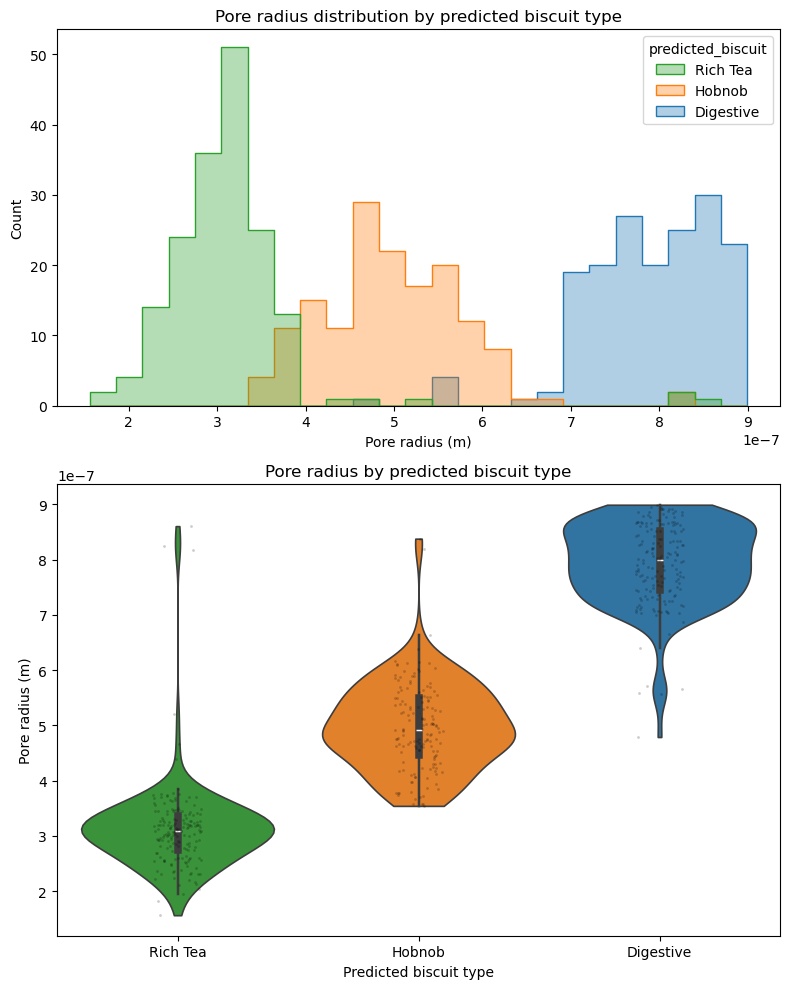

In [67]:
plt.tight_layout()
radius_col = 'r' 
class_col = 'predicted_biscuit'

order = ['Rich Tea','Hobnob','Digestive']
palette = {
    'Digestive': '#1f77b4',
    'Hobnob': '#ff7f0e',
    'Rich Tea': '#2ca02c'
}
plt.show()


fig, axes = plt.subplots(
    2, 1, figsize=(8, 10),
    gridspec_kw={'height_ratios': [1, 1.2]}
)

# Histogram
sns.histplot(
    data=micro,
    x=radius_col,
    hue=class_col,
    hue_order=order,
    palette=palette,
    bins=25,
    element='step',
    stat='count',
    common_norm=False,
    alpha=0.35,
    ax=axes[0]
)

axes[0].set_title('Pore radius distribution by predicted biscuit type')
axes[0].set_xlabel('Pore radius (m)')
axes[0].set_ylabel('Count')

# Violin
sns.violinplot(
    data=micro,
    x=class_col,
    y=radius_col,
    order=order,
    palette=palette,
    inner='box',
    cut=0,
    linewidth=1.2,
    ax=axes[1]
)

sns.stripplot(
    data=micro,
    x=class_col,
    y=radius_col,
    order=order,
    color='black',
    alpha=0.2,
    size=2,
    ax=axes[1]
)

axes[1].set_title('Pore radius by predicted biscuit type')
axes[1].set_xlabel('Predicted biscuit type')
axes[1].set_ylabel('Pore radius (m)')

plt.tight_layout()
plt.show()

In [68]:
means = []
variances = []

for biscuit in np.unique(micro['predicted_biscuit']):
    variance = np.var(micro[micro['predicted_biscuit'] == biscuit]['r'])
    mean = np.mean(micro[micro['predicted_biscuit'] == biscuit]['r'])
    means.append(mean)
    variances.append(variance)

means_vars = pd.DataFrame(data = {'predicted_biscuit':np.unique(micro['predicted_biscuit']),
                                   'mean': means,
                                  'variance':variances})
means_vars

,predicted_biscuit,mean,variance
0,Digestive,7.922873e-07,5.462300e-15
1,Hobnob,4.975634e-07,6.319329e-15
2,Rich Tea,3.133841e-07,7.176593e-15


Digestive > Hobnob > Rich Tea in effective radius, as seen from rad table and violin/hist plots. This furthers the conc that these biscuits have meaningful structural differences that informs L

# Radius Estimation

Can radius be predicted from experimental variables?

In [69]:
train, test = train_test_split(micro, test_size=0.2, random_state=42)
X = train.drop(['predicted_biscuit','prediction_confidence',	'prob_Rich_Tea',	'prob_Digestive',	'prob_Hobnob'], axis=1)

In [70]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_ = poly.fit_transform(X)
y = train['predicted_index']
X_.shape

(400, 35)

In [71]:
linear_regression = LinearRegression()
linear_regression.fit(X_, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
X_test = test.drop(['predicted_biscuit','prediction_confidence',	'prob_Rich_Tea',	'prob_Digestive',	'prob_Hobnob'], axis=1).values
X_test_ = poly.fit_transform(X_test)

In [73]:
y_test = test['predicted_index'].values
mean_squared_error(y_test , linear_regression.predict(X_test_))

2.8903636328031995e-28

In [74]:
linear_regression.coef_

array([ 1.82054816e-12, -5.08648404e-13,  6.34468749e-10, -1.49819066e-11,
        2.20821471e-15, -4.96712804e-08,  1.00000000e+00,  6.22477346e-13,
       -3.28250656e-13, -1.35286694e-09, -3.55955246e-11,  5.96629291e-16,
        4.39245652e-08, -8.09844225e-15,  1.57203519e-13,  5.61991778e-11,
        1.01962062e-11, -1.19201444e-15,  2.91257928e-08,  2.67890506e-15,
       -2.98378348e-07,  3.02390977e-09, -7.22933209e-13, -6.24679881e-11,
        1.75920712e-12,  2.18779696e-10, -9.54556425e-14, -2.42552467e-07,
        1.81489167e-13,  9.14296293e-17,  8.32269704e-12,  8.66457754e-17,
       -3.56108464e-11, -2.85363231e-10,  1.52582185e-16])

In [75]:
# ============================================================
# Section 3: Radius Estimation from Microscopy Data
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# Features and target
# ------------------------------------------------------------

features = ['gamma', 'phi', 'eta', 'L', 't']
target = 'r'

X = micro[features]
y = micro[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    )
}

# ------------------------------------------------------------
# Fit and evaluate
# ------------------------------------------------------------

results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

radius_results = pd.DataFrame(results)
radius_results

,Model,RMSE,MAE,R2
0,Linear Regression,1.276659e-07,1.018149e-07,0.639781
1,Random Forest,1.242317e-07,9.784027e-08,0.658900


In [76]:
# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():

    r2_scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='r2'
    )

    rmse_scores = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )

    cv_results.append({
        'Model': name,
        'Mean CV R2': r2_scores.mean(),
        'Std CV R2': r2_scores.std(),
        'Mean CV RMSE': rmse_scores.mean(),
        'Std CV RMSE': rmse_scores.std()
    })

radius_cv_results = pd.DataFrame(cv_results)
radius_cv_results

,Model,Mean CV R2,Std CV R2,Mean CV RMSE,Std CV RMSE
0,Linear Regression,0.639526,0.034386,1.292136e-07,5.025264e-09
1,Random Forest,0.641339,0.070896,1.282570e-07,1.202577e-08


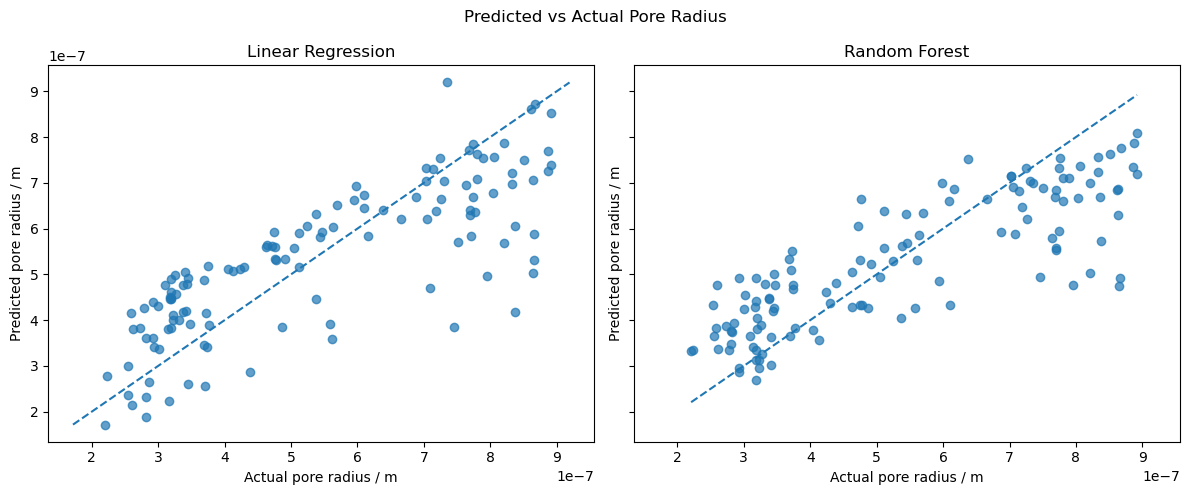

In [77]:
# ------------------------------------------------------------
# Predicted vs actual radius
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):

    ax.scatter(y_test, y_pred, alpha=0.7)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    ax.set_title(name)
    ax.set_xlabel('Actual pore radius / m')
    ax.set_ylabel('Predicted pore radius / m')

fig.suptitle('Predicted vs Actual Pore Radius')
fig.tight_layout()
plt.show()

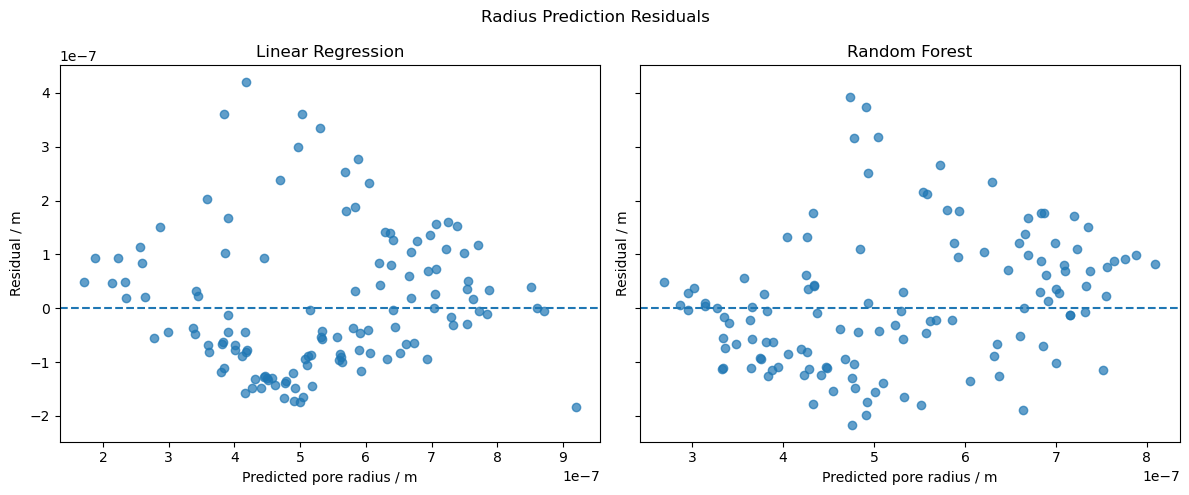

In [78]:
# ------------------------------------------------------------
# Residual analysis
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):

    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.7)
    ax.axhline(0, linestyle='--')

    ax.set_title(name)
    ax.set_xlabel('Predicted pore radius / m')
    ax.set_ylabel('Residual / m')

fig.suptitle('Radius Prediction Residuals')
fig.tight_layout()
plt.show()

In [79]:
# ------------------------------------------------------------
# Random Forest feature importance
# ------------------------------------------------------------

rf_model = models['Random Forest']

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

importance_df

,Feature,Importance
3,L,0.525337
1,phi,0.295179
4,t,0.103518
0,gamma,0.059025
2,eta,0.016941


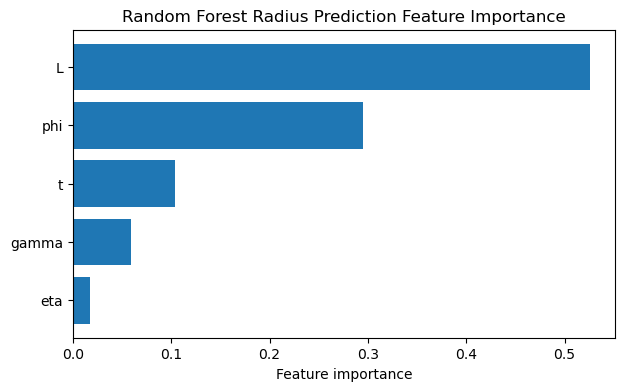

In [80]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

ax.invert_yaxis()
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest Radius Prediction Feature Importance')

plt.show()

This result is not suprisjng as it has already been clear that the L is the greatest variation within biscuit types and so this is a split in the feature space

## Washburn estimation

In [84]:
dunk = pd.read_csv('dunking-data.csv')

In [81]:
# ============================================================
# Section 4: Washburn Estimation of Capillary Rise L
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# Washburn equation
# L = sqrt((gamma * r * t * cos(phi)) / (2 * eta))
# ------------------------------------------------------------

def washburn_L(gamma, r, t, phi, eta):
    value = (gamma * r * t * np.cos(phi)) / (2 * eta)
    return np.sqrt(np.maximum(value, 0))

In [85]:
# ------------------------------------------------------------
# Mean radius for each biscuit type from microscopy data
# ------------------------------------------------------------

radius_summary = (
    micro
    .groupby('predicted_biscuit')['r']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'mean_r', 'std': 'std_r', 'count': 'n'})
)

radius_summary

,mean_r,std_r,n
predicted_biscuit,,,
Digestive,7.922873e-07,7.412316e-08,172
Hobnob,4.975634e-07,7.975527e-08,153
Rich Tea,3.133841e-07,8.495786e-08,175


In [87]:
# ------------------------------------------------------------
# Add mean radius to each dunking-data row by biscuit type
# ------------------------------------------------------------

dunk_washburn = dunk.copy()

dunk_washburn = dunk_washburn.merge(
    radius_summary[['mean_r']],
    left_on='biscuit',
    right_index=True,
    how='left'
)

# ------------------------------------------------------------
# Predict L using Washburn equation
# ------------------------------------------------------------

dunk_washburn['L_washburn'] = washburn_L(
    gamma=dunk_washburn['gamma'],
    r=dunk_washburn['mean_r'],
    t=dunk_washburn['t'],
    phi=dunk_washburn['phi'],
    eta=dunk_washburn['eta']
)

dunk_washburn[['biscuit', 'L', 'L_washburn', 'mean_r']]

,biscuit,L,L_washburn,mean_r
0,Digestive,0.011196,0.011562,7.922873e-07
1,Digestive,0.005894,0.005939,7.922873e-07
2,Digestive,0.009249,0.009035,7.922873e-07
3,Hobnob,0.003774,0.004438,4.975634e-07
4,Hobnob,0.002291,0.002119,4.975634e-07
...,...,...,...,...
2995,Digestive,0.003221,0.003333,7.922873e-07
2996,Hobnob,0.003933,0.004172,4.975634e-07
2997,Hobnob,0.007583,0.007034,4.975634e-07
2998,Digestive,0.013988,0.015007,7.922873e-07


In [88]:
# ------------------------------------------------------------
# Overall Washburn performance
# ------------------------------------------------------------

y_true = dunk_washburn['L']
y_pred = dunk_washburn['L_washburn']

washburn_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
washburn_mae = mean_absolute_error(y_true, y_pred)
washburn_r2 = r2_score(y_true, y_pred)

washburn_results = pd.DataFrame({
    'Model': ['Washburn'],
    'RMSE': [washburn_rmse],
    'MAE': [washburn_mae],
    'R2': [washburn_r2]
})

washburn_results

,Model,RMSE,MAE,R2
0,Washburn,0.000446,0.000325,0.980335


In [89]:
# ------------------------------------------------------------
# Washburn performance for each biscuit type
# ------------------------------------------------------------

washburn_by_biscuit = []

for biscuit, df in dunk_washburn.groupby('biscuit'):

    rmse = np.sqrt(mean_squared_error(df['L'], df['L_washburn']))
    mae = mean_absolute_error(df['L'], df['L_washburn'])
    r2 = r2_score(df['L'], df['L_washburn'])

    washburn_by_biscuit.append({
        'Biscuit': biscuit,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

washburn_by_biscuit = pd.DataFrame(washburn_by_biscuit)
washburn_by_biscuit

,Biscuit,RMSE,MAE,R2
0,Digestive,0.000328,0.000257,0.991691
1,Hobnob,0.000525,0.000386,0.966228
2,Rich Tea,0.000463,0.000330,0.953653


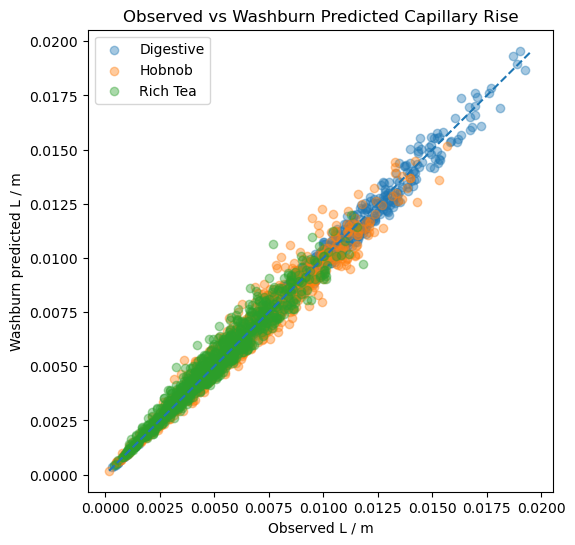

In [91]:
# ------------------------------------------------------------
# Actual L vs Washburn-predicted L
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6))

for biscuit, df in dunk_washburn.groupby('biscuit'):
    ax.scatter(
        df['L'],
        df['L_washburn'],
        alpha=0.4,
        label=biscuit
    )

min_val = min(dunk_washburn['L'].min(), dunk_washburn['L_washburn'].min())
max_val = max(dunk_washburn['L'].max(), dunk_washburn['L_washburn'].max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')

ax.set_xlabel('Observed L / m')
ax.set_ylabel('Washburn predicted L / m')
ax.set_title('Observed vs Washburn Predicted Capillary Rise')
ax.legend()

plt.show()

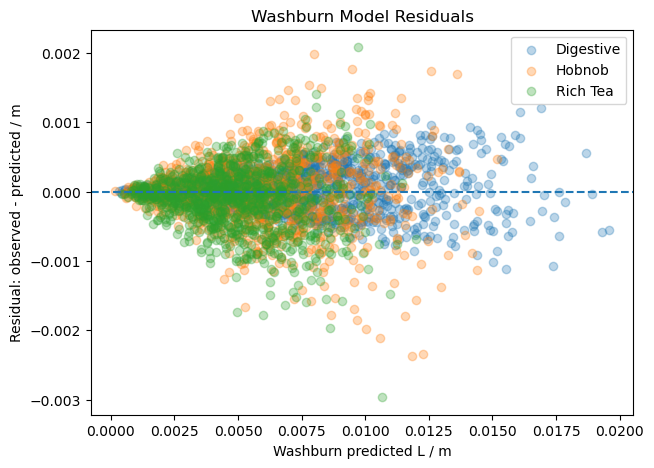

In [93]:
# ------------------------------------------------------------
# Washburn residuals
# ------------------------------------------------------------

dunk_washburn['washburn_residual'] = (
    dunk_washburn['L'] - dunk_washburn['L_washburn']
)

fig, ax = plt.subplots(figsize=(7, 5))

for biscuit, df in dunk_washburn.groupby('biscuit'):
    ax.scatter(
        df['L_washburn'],
        df['washburn_residual'],
        alpha=0.3,
        label=biscuit
    )

ax.axhline(0, linestyle='--')

ax.set_xlabel('Washburn predicted L / m')
ax.set_ylabel('Residual: observed - predicted / m')
ax.set_title('Washburn Model Residuals')
ax.legend()

plt.show()

In [94]:
# ------------------------------------------------------------
# Relative error
# ------------------------------------------------------------

dunk_washburn['relative_error'] = (
    np.abs(dunk_washburn['L'] - dunk_washburn['L_washburn'])
    / dunk_washburn['L']
)

relative_error_summary = (
    dunk_washburn
    .groupby('biscuit')['relative_error']
    .agg(['mean', 'std', 'median'])
)

relative_error_summary

,mean,std,median
biscuit,,,
Digestive,0.032309,0.019125,0.031094
Hobnob,0.066840,0.054160,0.055781
Rich Tea,0.071964,0.066937,0.055213
